# Advanced Disk Modeling

This tutorial builds on the fundamental disk modeling tutorial to show a parameter estimation for real data using MCMC---we use the affine-invariant ensemble sampler implementation of MCMC from [`emcee`](https://emcee.readthedocs.io/en/stable/) ([Foreman-Mackey+ 2012](https://arxiv.org/abs/1202.3665)).

The data used in this tutorial is HD 115600 in H-band polarimetry from the Gemini Planet Imager debris disk survey ([Esposito+ 2020](https://iopscience.iop.org/article/10.3847/1538-3881/ab9199/meta)), and is publicly available on the CANFAR archive ([Crotts+ 2025](https://iopscience.iop.org/article/10.3847/1538-4365/ad90a4/pdf)).

In [1]:
from astropy.io import fits

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

import os
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.40'

jax.config.update("jax_enable_x64", True)

### Loading and Processing Files

For this tutorial using real data, we begin with starting parameter guesses from published literature values where possible. 

In [2]:
# GPI Image Initial Parameter Reference

# Name             Radius   Inclination  Position Angle Distance  Knots                                                  
# hd111161_H_pol    72.4         62.1        263.2        109.43      5
# hr4796a_H_pol     78.5         76.5         26.1         72.78      7
# hd115600_H_pol	46.0	     80.0	      27.5	      109.62	  6

row = {'Name': 'hd115600_H_pol', 'Radius': 51.0, 'Inclination': 85.0, "Position Angle": 27.5, "Distance": 109.62, "Knots": 6}


2026-04-06 15:04:52.895439: W external/xla/xla/service/gpu/nvptx_compiler.cc:930] The NVIDIA driver's CUDA version is 12.2 which is older than the PTX compiler version 12.9.86. Because the driver is older than the PTX compiler version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


Filename: tutorial_images/hd115600_H_pol.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     523   ()      
  1  SCI           1 ImageHDU       142   (281, 281, 4)   float32   
  2  DQ            3 ImageHDU        64   (281, 281, 2)   uint8   


Text(0.5, 1.0, 'HD 115600 Image from Fits File')

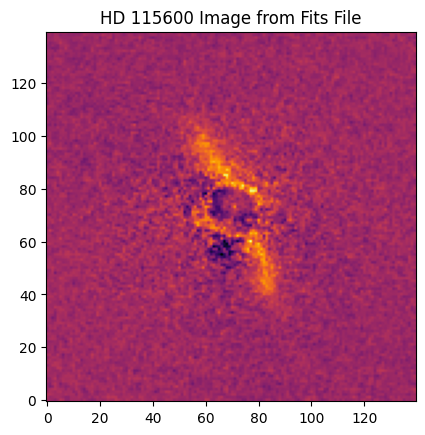

In [3]:
from grater_jax.optimization.optimize_framework import OptimizeUtils

fits_image_filepath = "tutorial_images/" + row['Name'] + ".fits"
hdul = fits.open(fits_image_filepath)

#Displays File Info
hdul.info()

# Gets Image
target_image = OptimizeUtils.process_image(hdul['SCI'].data[1,:,:], bounds=(70, 210, 70, 210))

# Displays Image
plt.imshow(target_image, origin='lower', cmap='inferno')
plt.title("HD 115600 Image from Fits File")

### Getting Optimal Disk Fit

In [4]:
from grater_jax.optimization.optimize_framework import Optimizer, OptimizeUtils
from grater_jax.disk_model.objective_functions import objective_model, objective_ll, objective_fit, Parameter_Index
from grater_jax.disk_model.SLD_ojax import ScatteredLightDisk
from grater_jax.disk_model.SLD_utils import *

#### Initializing Relevant Parameters

The disk fit begins with processing the target image and creating an error map, setting up the empirical PSF (if desired), and then initializing a disk model in the optimizer class with some starting parameters.

The error map is generated from the $U_\phi$ image of the GPI polarimetric data, as that should be an estimate of the noise and should *not* contain disk signal.

In [5]:
target_image = OptimizeUtils.process_image(hdul['SCI'].data[1,:,:], bounds=(70, 210, 70, 210))
err_map = OptimizeUtils.process_image(OptimizeUtils.create_empirical_err_map(hdul['SCI'].data[2,:,:]), bounds=(70, 210, 70, 210)) #, outlier_pixels=[(57, 68)]))

/home/blewis/anaconda3/envs/grater-test/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


In [6]:
scale_factor = 1
image = fits.open("tutorial_images/GPI_Hband_PSF.fits")[0].data[0,:,:]
scaled_image = (image[::scale_factor, ::scale_factor])[1::, 1::]
cropped_image = image[70:211, 70:211]
def safe_float32_conversion(value):
    try:
        return np.float32(value)
    except (ValueError, TypeError):
        print("This value is unjaxable: " + str(value))
emp_psf_image = np.nan_to_num(cropped_image)
emp_psf_image = np.vectorize(safe_float32_conversion)(emp_psf_image)

There are three setup steps before optimization:

1. **`opt.inc_bound_knots()`** — Uses the starting inclination guess to set `forwardscatt_bound` and `backscatt_bound`, restricting knots to the scattering angles actually probed at this inclination. A face-on disk probes a narrow angular range and needs fewer knots than an edge-on one. Only use this if you have a reasonable inclination estimate. Values outside the knot range are extrapolated: linear on the forward scattering side (to capture physically motivated forward-scattering behavior), and constant at the backscattering boundary.

2. **`opt.set_empirical_psf(emp_psf_image)`** — Loads the empirical PSF image into the `EMP_PSF` class. Only needed when using an empirical PSF.

3. **`opt.warm_start_knots(init_g=0.5)`** — The spline SPF is normalized to 1 at 90 degrees (cos_phi = 0) by construction, so `flux_scaling` carries the absolute brightness. This method initialises knot values from a normalized Henyey-Greenstein shape evaluated at each free knot position, avoiding the flat-spline local minimum that an all-ones initialization produces at low inclinations. `init_g` is an assumed asymmetry parameter — not a constraint on the fit.

4. **`opt.estimate_flux_scaling(target_image)`** — Estimates a starting `flux_scaling` by matching the model peak to the 99th-percentile brightness of unmasked pixels in the target image. Both `knot_values` and `flux_scaling` are then fit jointly by the optimizer. This is just one way of getting an estimated flux scaling to start, and the user is ultimately responsible for finding a starting flux scaling that works for their data.

If you have a coronagraph with substantial throughput loss beyond the mask position, it may be preferable to include this throughput correction in the modeling. If this is the case, you can create your own map of throughput and pass it to `opt.set_throughput()`

In [ ]:
start_disk_params = Parameter_Index.disk_params.copy()
start_spf_params = InterpolatedUnivariateSpline_SPF.params.copy()
start_psf_params = EMP_PSF.params.copy()
start_misc_params = Parameter_Index.misc_params.copy()

start_disk_params["sma"] = row["Radius"]
start_disk_params["inclination"] = row["Inclination"]
start_disk_params["position_angle"] = row["Position Angle"]
start_spf_params["num_knots"] = int(row["Knots"])
start_misc_params["distance"] = row["Distance"]
start_disk_params["x_center"] = target_image.shape[1] / 2
start_disk_params["y_center"] = target_image.shape[0] / 2

opt = Optimizer(ScatteredLightDisk, DustEllipticalDistribution2PowerLaws, InterpolatedUnivariateSpline_SPF, EMP_PSF,
                start_disk_params, start_spf_params, start_psf_params, start_misc_params)

# Set knot angle bounds from the assumed inclination.
opt.inc_bound_knots()
opt.set_empirical_psf(emp_psf_image)

# Apply the GPI coronagraph throughput map. This accounts for the position-dependent
# attenuation of the coronagraph across the field of view.
from astropy.io import fits as astrofits
throughput = astrofits.open("/home/blewis/GRaTeR-JAX/PSFs/GPI_H_throughput_map.fits")[0].data
opt.set_throughput(throughput)

# Warm-start knot values from a normalised HG shape evaluated at the free knot positions.
# init_g is the assumed asymmetry parameter — not a constraint on the fit.
opt.warm_start_knots(init_g=0.5)

# Estimate a starting flux_scaling by matching the model peak to the target image.
flux_scaling = opt.estimate_flux_scaling(target_image)
print(f"Estimated flux_scaling: {flux_scaling:.3g}")

### JIT Compiling and Disk Modeling

If you would like to use the gradient functionality in your models, you need to explicitly compile the gradient for the JIT compilation using `opt.jit_compile_gradient` as shown below.

In [8]:
opt.jit_compile_model() # <-- opt.log_likelihood is also jit compiled by this
opt.jit_compile_gradient(target_image, err_map) # <-- Not needed if gradient isn't going to be used

In [9]:
print(opt.log_likelihood(target_image, err_map))
opt.get_gradient(['sma', 'alpha_in', 'knot_values'], target_image, err_map)

-2.2395662843411177


[Array(0.00116421, dtype=float64),
 Array(0.00097864, dtype=float64),
 Array([ 5.03808911e-05,  3.00519104e-03,  1.37560085e-03,  3.52337737e-04,
        -1.89308077e-03, -9.94898145e-04], dtype=float64)]

Text(0.5, 1.0, 'Initial Guess, Log-Likelihood: -2.2395662843411177')

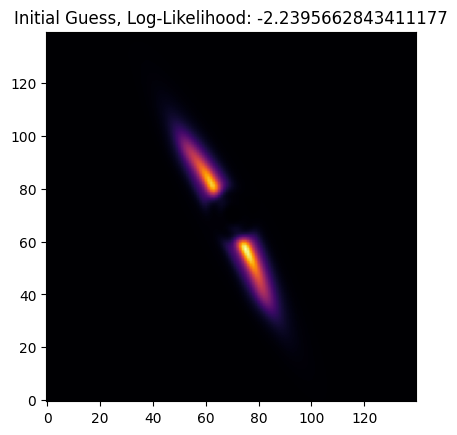

In [10]:
plt.imshow(opt.get_model(), origin='lower', cmap='inferno')
plt.title(f"Initial Guess, Log-Likelihood: {opt.log_likelihood(target_image, err_map)}")

In [11]:
opt.print_params()

Disk Params: {'accuracy': 0.005, 'alpha_in': 5, 'alpha_out': -5, 'sma': 51.0, 'e': 0.0, 'ksi0': 3.0, 'gamma': 2.0, 'beta': 1.0, 'rmin': 0.0, 'dens_at_r0': 1.0, 'inclination': 85.0, 'position_angle': 27.5, 'x_center': 70.0, 'y_center': 70.0, 'omega': 0.0}
SPF Params: {'backscatt_bound': Array(-0.9961947, dtype=float64, weak_type=True), 'forwardscatt_bound': Array(0.9961947, dtype=float64, weak_type=True), 'num_knots': 6, 'knot_values': Array([10.92984453,  3.11646968,  1.58908473,  0.70230955,  0.52772533,
        0.41513937], dtype=float64)}
PSF Params: {'scale_factor': 1.0, 'offset': 1.0}
Stellar PSF Params: None
Misc Params: {'distance': 109.62, 'pxInArcsec': 0.01414, 'nx': 140, 'ny': 140, 'halfNbSlices': 25, 'flux_scaling': 255.12246762751974}


JAX can be particularly troublesome with NaNs and infinities, as it does not handle them as Numpy does---the below functions can be enabled to help debug JAX errors that may arise.

In [12]:
# Can enable these to debug jax issues
# jax.config.update('jax_debug_nans', True)
# jax.config.update('jax_debug_infs', True)

### Running Optimization

With the `Optimizer` class, parameters to fit are specified with `fit_keys`. Any key from `disk_params`, `spf_params`, `psf_params`, or `misc_params` can be included. Log-scaling a parameter (via `logscaled_params`) helps when it may span orders of magnitude — the optimizer works in log space and the result is automatically exponentiated back. Array-valued parameters like `knot_values` must be listed in `array_params` as well.

Since the spline SPF is normalized to 1 at 90 degrees, `flux_scaling` is the true absolute brightness of the model. We include it in `fit_keys` and log-scale it so the optimizer finds the correct brightness alongside the disk geometry and SPF shape. Running scipy first (before MCMC) gives a good starting point that reduces burn-in time.

It is also sometimes helpful to run the scipy optimization *twice* to reset the optimizer if you have a particularly tricky disk. This is demonstrated below.

In [ ]:
fit_keys = ['alpha_in', 'alpha_out', 'sma', 'inclination', 'position_angle', 'x_center', 'y_center', 'knot_values', 'e', 'flux_scaling']
# Log-scale knot_values (can span orders of magnitude) and flux_scaling (same reason).
logscaled_params = ['knot_values', 'flux_scaling']
array_params = ['knot_values']

nk = opt.spf_params["num_knots"]
bounds = (
    [0.1,  -15,   0,    0,    0,   60,  60,  np.ones(nk)*1e-4,     0,    1e-2],
    [20,   -0.1, 150,  180,  400,  80,  80,  1e4*np.ones(nk),      1,    1e8 ],
)

opt.scipy_bounded_optimize(fit_keys, bounds, logscaled_params, array_params, target_image, err_map,
                           use_grad=True, disp_soln=True, iters=2000)

# Second scipy pass: reset Hessian and continue from current solution.
opt.scipy_bounded_optimize(fit_keys, bounds, logscaled_params, array_params, target_image, err_map,
                           use_grad=True, disp_soln=True, iters=2000, maxls=50)
optimal_image = opt.get_model()

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =           15     M =           10

At X0         1 variables are exactly at the bounds

At iterate    0    f=  2.23957D+00    |proj g|=  1.56992D-02

At iterate    1    f=  2.23890D+00    |proj g|=  1.50911D-02



At iterate    2    f=  2.19638D+00    |proj g|=  4.05187D-02



At iterate    3    f=  2.19447D+00    |proj g|=  8.13529D-02



At iterate    4    f=  2.19305D+00    |proj g|=  6.52120D-02
  Positive dir derivative in projection 
  Using the backtracking step 

At iterate    5    f=  2.18002D+00    |proj g|=  5.25196D-02
  Positive dir derivative in projection 
  Using the backtracking step 

At iterate    6    f=  2.17964D+00    |proj g|=  2.87951D-02



At iterate    7    f=  2.17249D+00    |proj g|=  4.22885D-02


...


At iterate    9    f=  2.16467D+00    |proj g|=  2.58431D-03

At iterate   10    f=  2.16455D+00    |proj g|=  4.95227D-03

At iterate   11    f=  2.16434D+00    |proj g|=  4.86315D-03



At iterate   12    f=  2.16376D+00    |proj g|=  5.36984D-03



At iterate   13    f=  2.16352D+00    |proj g|=  4.83360D-03


  message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
  success: True
   status: 0
      fun: 2.1635185790874303
        x: [ 5.468e+00 -5.136e+00 ...  2.112e-02  5.881e+00]
      nit: 14
      jac: [ 9.372e-05  2.800e-03 ...  2.960e-03  4.834e-03]
     nfev: 42
     njev: 42
 hess_inv: <15x15 LbfgsInvHessProduct with dtype=float64>

At iterate   14    f=  2.16352D+00    |proj g|=  4.83360D-03

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
   15     14     44     14     0     0   4.834D-03   2.164D+00
  F =   2.1635185790874303     

CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH             



   evaluations in the last line search.  Termination
   may possibly be caused by a bad search direction.


### Results

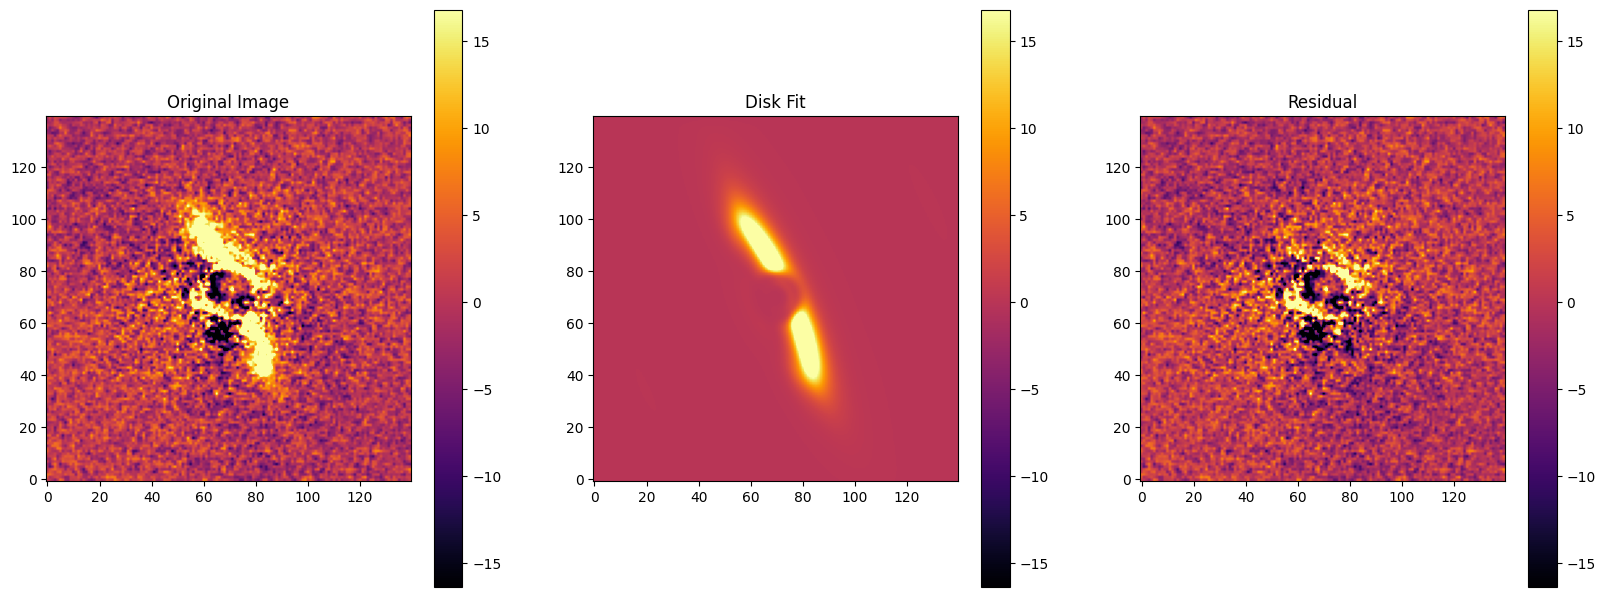

In [14]:
fig, axes = plt.subplots(1,3, figsize=(20,10))

mask = OptimizeUtils.get_mask(target_image)
vmin = np.nanpercentile(target_image[mask], 10)
vmax = np.nanpercentile(target_image[mask], 90)

im = axes[0].imshow(target_image, origin='lower', cmap='inferno')
axes[0].set_title("Original Image")
plt.colorbar(im, ax=axes[0], shrink=0.75)
im.set_clim(vmin, vmax)

im = axes[1].imshow(optimal_image, origin='lower', cmap='inferno')
axes[1].set_title("Disk Fit")
plt.colorbar(im, ax=axes[1], shrink=0.75)
im.set_clim(vmin, vmax)

im = axes[2].imshow(target_image-optimal_image, origin='lower', cmap='inferno')
axes[2].set_title("Residual")
plt.colorbar(im, ax=axes[2], shrink=0.75)
im.set_clim(vmin, vmax)

Since the spline SPF is internally normalized to 1 at 90 degrees (cos_phi = 0), `flux_scaling` is already the true physical flux normalization and no additional rescaling is needed after the fit. The parameters below reflect the best-fit values found by scipy.

In [15]:
opt.print_params()

Disk Params: {'accuracy': 0.005, 'alpha_in': 5.4684921337803685, 'alpha_out': -5.136079630123567, 'sma': 51.28267006790856, 'e': 0.021118224448588466, 'ksi0': 3.0, 'gamma': 2.0, 'beta': 1.0, 'rmin': 0.0, 'dens_at_r0': 1.0, 'inclination': 77.88732393436861, 'position_angle': 24.12528555552158, 'x_center': 71.01650962277627, 'y_center': 71.3548821300597, 'omega': 0.0}
SPF Params: {'backscatt_bound': Array(-0.9961947, dtype=float64, weak_type=True), 'forwardscatt_bound': Array(0.9961947, dtype=float64, weak_type=True), 'num_knots': 6, 'knot_values': array([12.58912098,  7.35183648,  4.13020745,  0.79213321,  0.21587119,
        0.2836615 ])}
PSF Params: {'scale_factor': 1.0, 'offset': 1.0}
Stellar PSF Params: None
Misc Params: {'distance': 109.62, 'pxInArcsec': 0.01414, 'nx': 140, 'ny': 140, 'halfNbSlices': 25, 'flux_scaling': 358.330009091058}


## Running MCMC

For MCMC, we recommend log-scaling `knot_values` and `flux_scaling` — log-space sampling keeps the chains well-conditioned when values can span orders of magnitude. The `Optimizer` passes them in as logarithms and exponentiates them internally.

The chain is saved during the run via `emcee`'s HDF5 backend. If a backend file already exists a confirmation prompt will appear unless `confirm_overwrite=False` is set (useful in scripted or non-interactive contexts). The default backend filename is `test_emcee_backend.h5`; change `opt.name` to use a different prefix.

**The chain used here is far too short for reliable parameter estimation** and is provided only to show the workflow. Consult the `emcee` documentation on autocorrelation-based convergence diagnostics to determine appropriate chain lengths for your science case.

Note that MCMC is *not* compatible with automatic differentiation! However, it still benefits from the speed ups from GPUs and JIT.

In [16]:
fit_keys = ['alpha_in', 'alpha_out', 'sma', 'inclination', 'position_angle', 'x_center', 'y_center', 'knot_values', 'e', 'flux_scaling']
logscaled_params = ['knot_values', 'flux_scaling']
array_params = ['knot_values']

nk = opt.spf_params["num_knots"]
bounds = (
    [0.1,  -15,   0,    0,    0,   60,  60,  np.ones(nk)*1e-4,     0,    1e-2],
    [200,  -0.1, 150,  180,  400,  80,  80,  1e4*np.ones(nk),      1,    1e8 ],
)

mc_model = opt.mcmc(fit_keys, logscaled_params, array_params, target_image, err_map, bounds,
                    nwalkers=100, niter=100, burns=20, confirm_overwrite=False)

Running burn-in...



  0%|          | 0/20 [00:00<?, ?it/s]


  5%|▌         | 1/20 [00:00<00:11,  1.66it/s]


 10%|█         | 2/20 [00:01<00:11,  1.64it/s]


 15%|█▌        | 3/20 [00:01<00:10,  1.63it/s]

...


 97%|█████████▋| 97/100 [00:43<00:01,  2.81it/s]


 98%|█████████▊| 98/100 [00:43<00:00,  2.86it/s]


 99%|█████████▉| 99/100 [00:44<00:00,  2.73it/s]


100%|██████████| 100/100 [00:44<00:00,  2.70it/s]


100%|██████████| 100/100 [00:44<00:00,  2.25it/s]

The function `model_obj.get_theta_median` will return the median parameters as estimated by the MCMC. Setting `scaled = True` will return the scaled spline SPF values (i.e. un-log-scaled).

In [17]:
mc_soln = mc_model.get_theta_median(scaled = True)
img = opt.get_model()

Text(0.5, 1.0, 'Post MCMC Residuals')

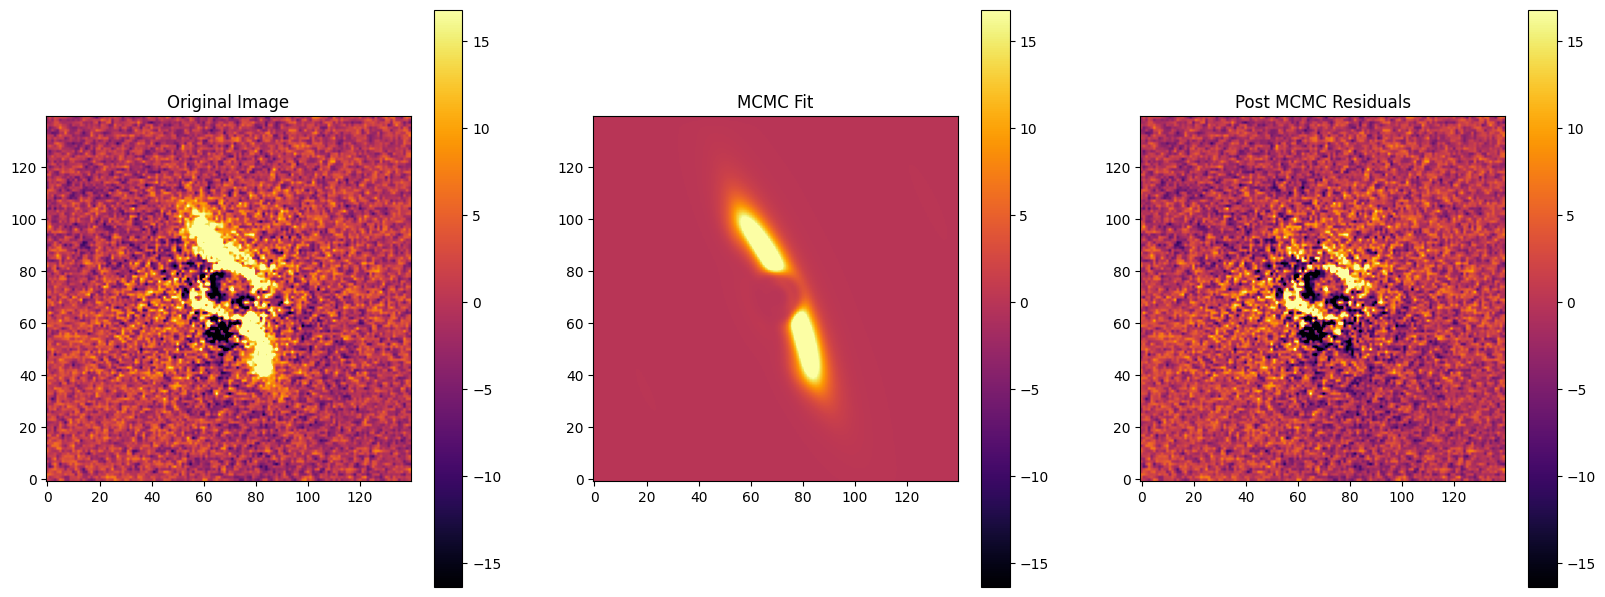

In [18]:
fig, axes = plt.subplots(1,3, figsize=(20,10))

mask = OptimizeUtils.get_mask(target_image)
vmin = np.nanpercentile(target_image[mask], 10)
vmax = np.nanpercentile(target_image[mask], 90)

im = axes[0].imshow(target_image, origin='lower', cmap='inferno')
axes[0].set_title("Original Image")
plt.colorbar(im, ax=axes[0], shrink=0.75)
im.set_clim(vmin, vmax)

im = axes[1].imshow(img, origin='lower', cmap='inferno')
axes[1].set_title("MCMC Fit")
plt.colorbar(im, ax=axes[1], shrink=0.75)
im.set_clim(vmin, vmax)

im = axes[2].imshow(target_image-img, origin='lower', cmap='inferno')
axes[2].set_title("Residual")
plt.colorbar(im, ax=axes[2], shrink=0.75)
im.set_clim(vmin, vmax)
plt.title("Post MCMC Residuals")

### Plotting MCMC Results

Various MCMC diagnostics are incorporated into the `optimizer` class, such as viewing the MCMC chains and creating a corner plot with [`corner.py`](https://corner.readthedocs.io/en/latest/). Again, you can use the boolean keyword `scaled` to scale the spline SPF chains and resulting parameters automatically. Labels for the chains must be entered, and are almost equivalent to the `fit_keys` list, except for any array-like parameters (e.g. the knot values).

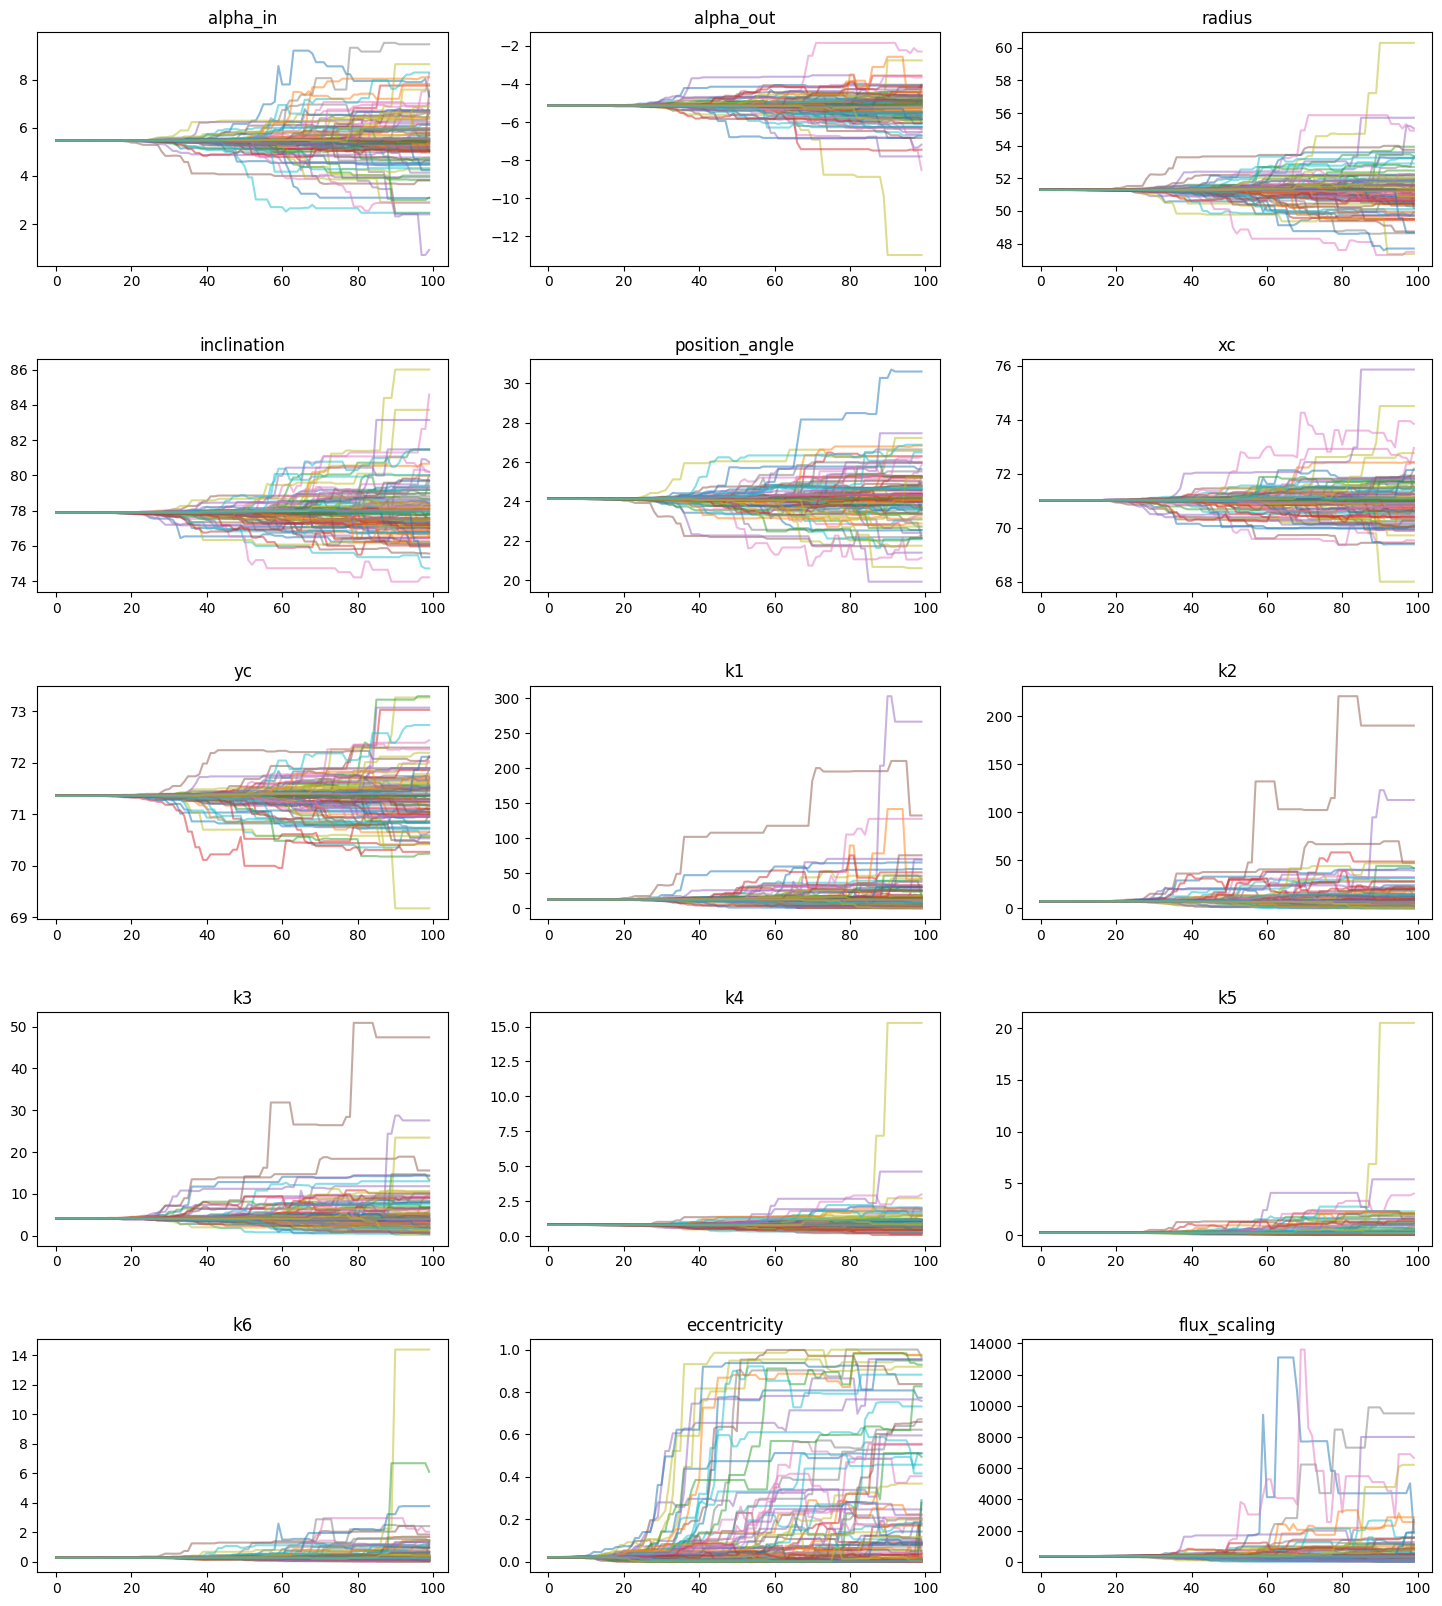

In [19]:
# Labels must match the order of fit_keys, with array parameters (knot_values)
# expanded into individual entries. fit_keys = ['alpha_in', 'alpha_out', 'sma',
# 'inclination', 'position_angle', 'x_center', 'y_center', 'knot_values', 'e', 'flux_scaling']
labels = ['alpha_in', 'alpha_out', 'radius', 'inclination', 'position_angle', 'xc', 'yc']
for i in range(0, opt.spf_params['num_knots']):
    labels.append('k'+str(i+1))
labels.append('eccentricity')
labels.append('flux_scaling')
mc_model.plot_chains(labels, scaled=True)

### Corner Plot

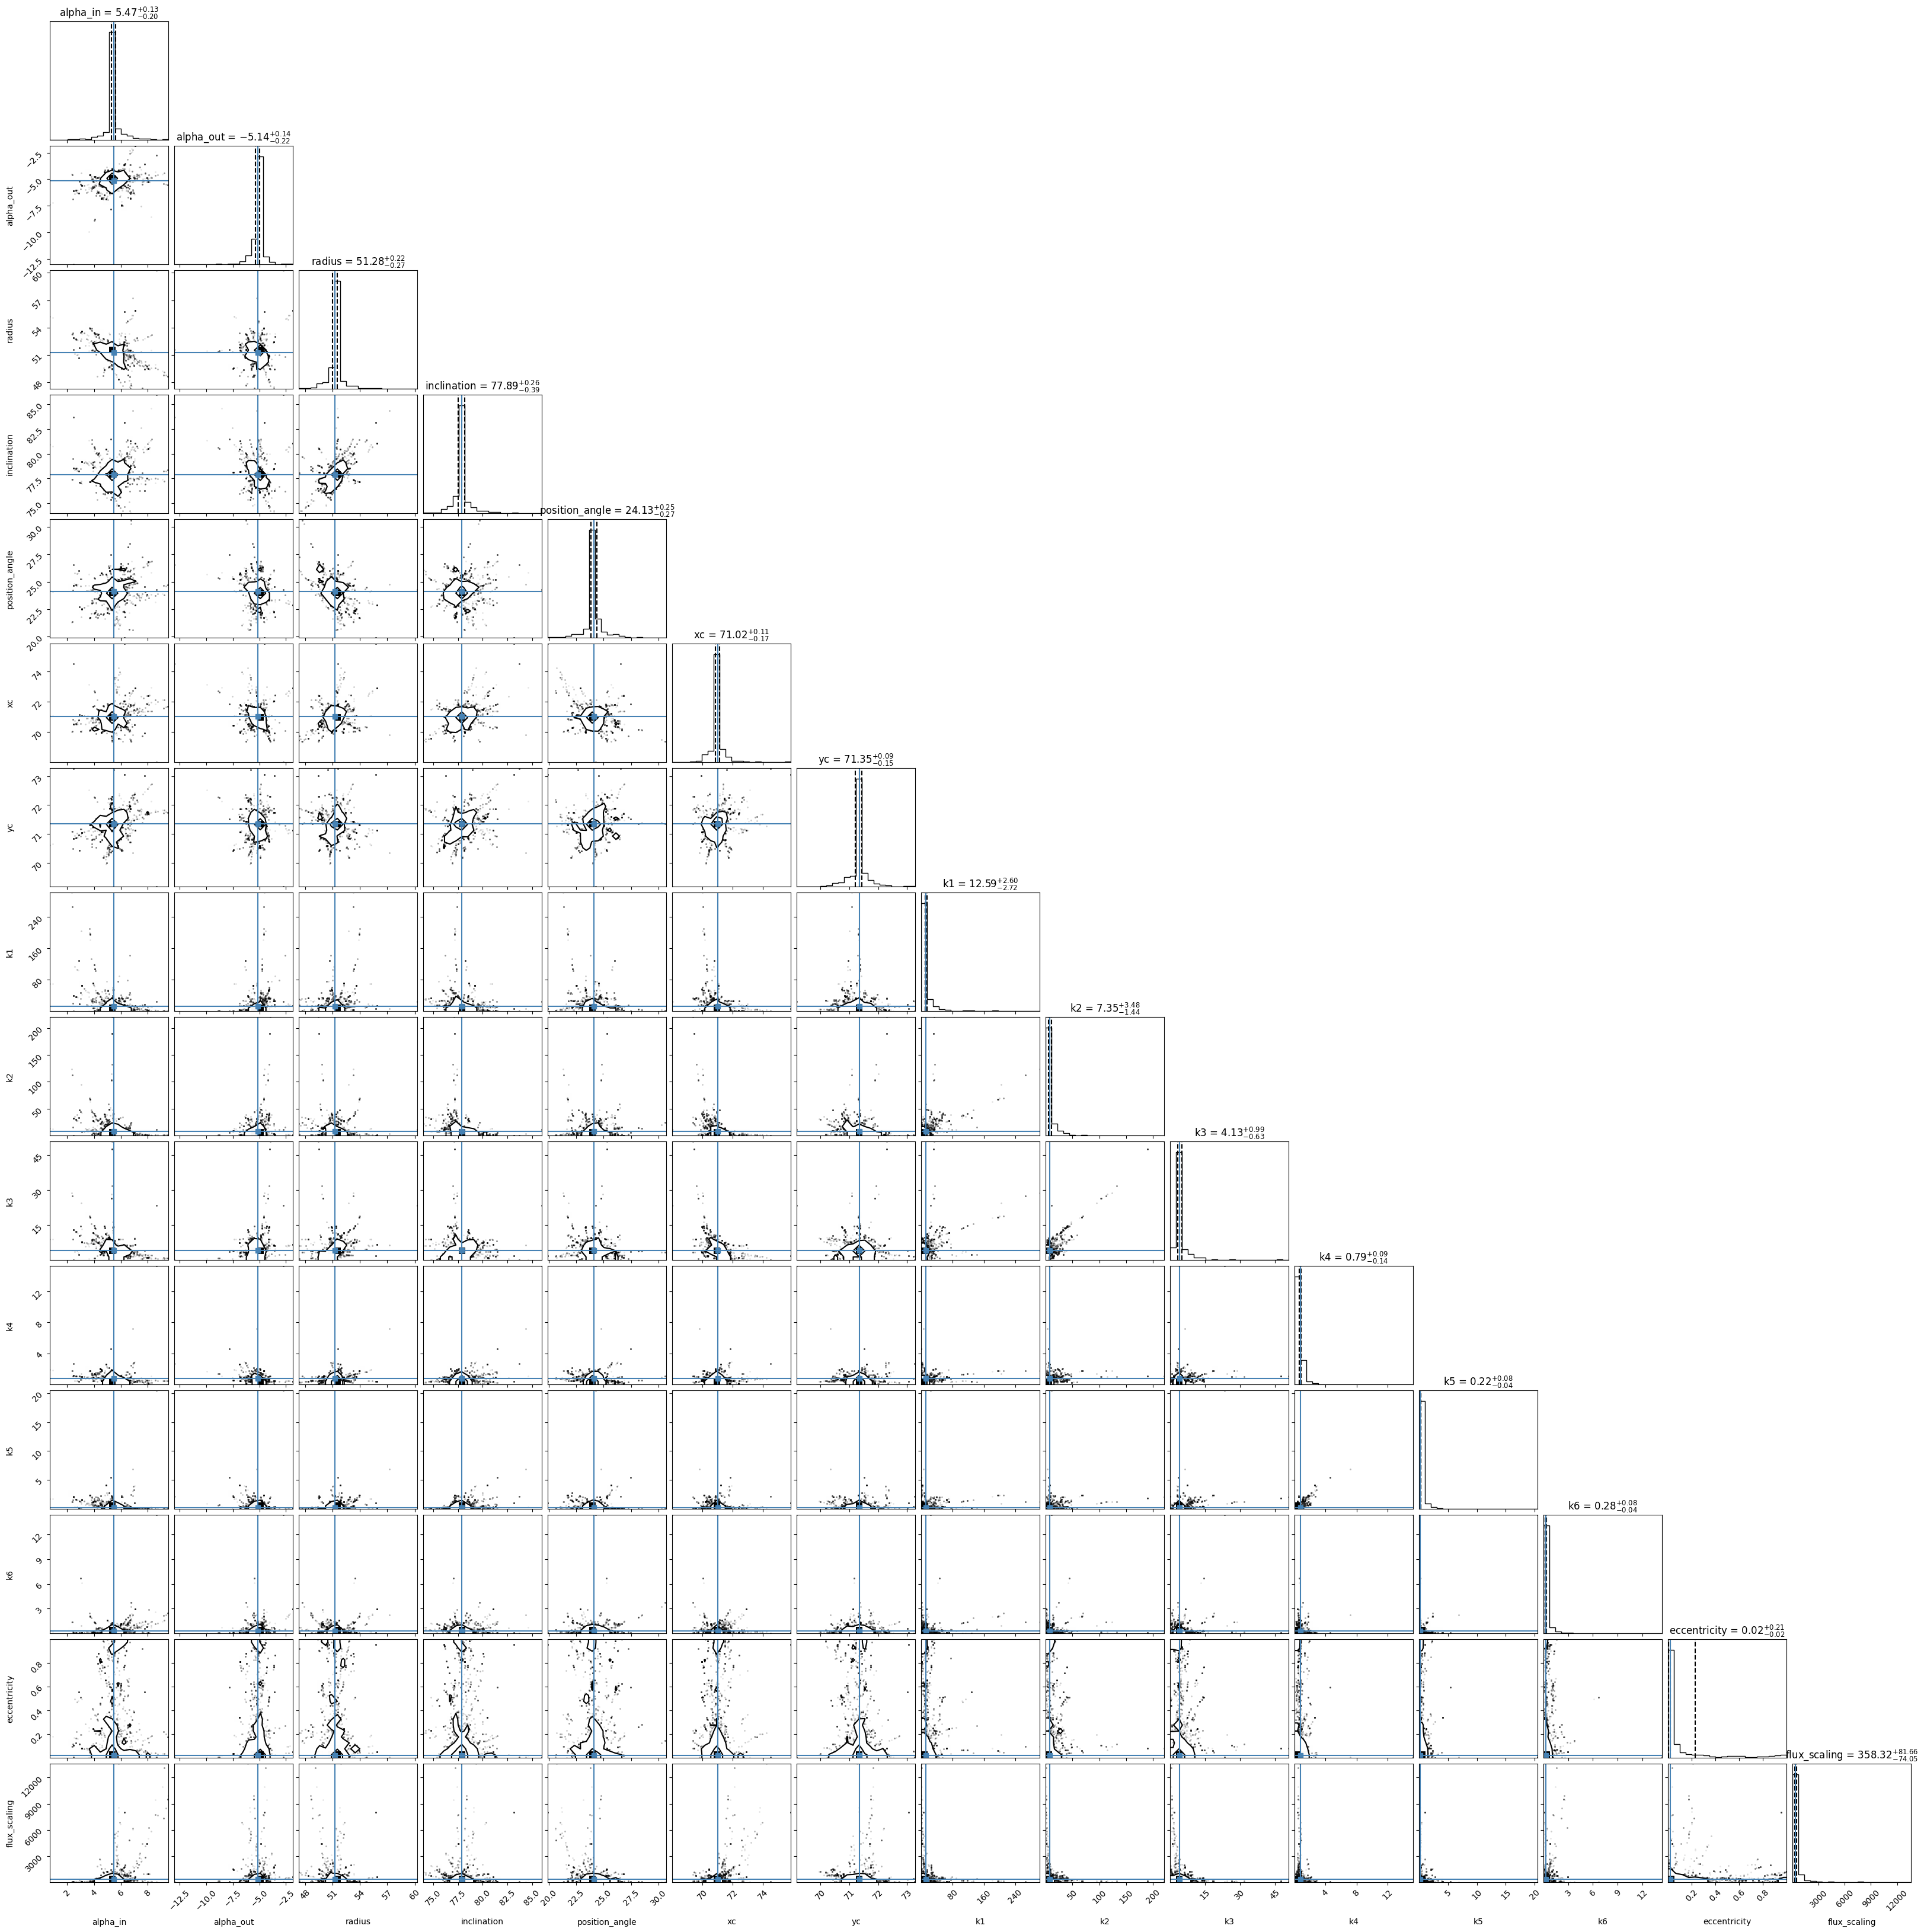

In [20]:
fig = mc_model.show_corner_plot(labels, truths=mc_soln, scaled = True, quiet = True)

In [21]:
print(dict(zip(labels, mc_model.get_theta_median(scaled=True))))

{'alpha_in': 5.468458598212051, 'alpha_out': -5.136178401528159, 'radius': 51.282645144266816, 'inclination': 77.88730688069282, 'position_angle': 24.125305512591325, 'xc': 71.01650791135636, 'yc': 71.35488583038844, 'k1': 12.589165496391448, 'k2': 7.3519016054779325, 'k3': 4.130101004308481, 'k4': 0.792113281038302, 'k5': 0.21592718271634617, 'k6': 0.283650852608359, 'eccentricity': 0.021612624291099992, 'flux_scaling': 358.31803692408425}
